<a href="https://colab.research.google.com/github/Nitin22122/DL-Lab/blob/main/Text_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score
import math

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
text = """Machine learning is a branch of artificial intelligence and computer science which focuses on the use of data and algorithms to imitate the way that humans learn gradually improving its accuracy. Deep learning is a specialized form of machine learning. A deep learning model is designed to continually analyze data with a logic structure similar to how a human would draw conclusions. To achieve this deep learning applications use a layered structure of algorithms called an artificial neural network. The design of such an artificial neural network is inspired by the biological neural network of the human brain."""

tokens = text.lower().replace('.', '').replace(',', '').split()

In [ ]:
counter = Counter(tokens)
vocab = {word: idx+1 for idx, (word, _) in enumerate(counter.items())}
vocab['<PAD>'] = 0
idx_to_word = {v: k for k, v in vocab.items()}
VOCAB_SIZE = len(vocab)

encoded = [vocab[w] for w in tokens]

In [ ]:
SEQ_LENGTH = 3
sequences = []

for i in range(len(encoded) - SEQ_LENGTH):
    seq_in = encoded[i:i+SEQ_LENGTH]
    seq_out = encoded[i+SEQ_LENGTH]
    sequences.append((seq_in, seq_out))

X = torch.tensor([s[0] for s in sequences], dtype=torch.long).to(device)
y = torch.tensor([s[1] for s in sequences], dtype=torch.long).to(device)

In [ ]:
class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embeds = self.embedding(x)
        out, hidden = self.lstm(embeds, hidden)
        out = self.dropout(out[:, -1, :])
        logits = self.fc(out)
        return logits, hidden

In [ ]:
EMBED_DIM = 64
HIDDEN_DIM = 128
NUM_LAYERS = 2
NUM_EPOCHS = 90
LR = 0.005

model = RNNLanguageModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.5)

train_losses = []
train_accuracies = []

print("─" * 40)
print("Training...")
print("─" * 40)

for epoch in range(NUM_EPOCHS):

    model.train()
    optimizer.zero_grad()

    logits, _ = model(X)
    loss = criterion(logits, y)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    optimizer.step()
    scheduler.step()

    preds = torch.argmax(logits, dim=1)
    acc = (preds == y).float().mean().item() * 100

    train_losses.append(loss.item())
    train_accuracies.append(acc)

    if (epoch + 1) % 15 == 0:
        print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] | "
              f"Loss: {loss.item():.4f} | Accuracy: {acc:.2f}%")

────────────────────────────────────────
Training...
────────────────────────────────────────
Epoch [ 15/90] | Loss: 1.8507 | Accuracy: 55.79%
Epoch [ 30/90] | Loss: 0.2559 | Accuracy: 96.84%
Epoch [ 45/90] | Loss: 0.0794 | Accuracy: 98.95%
Epoch [ 60/90] | Loss: 0.0674 | Accuracy: 97.89%
Epoch [ 75/90] | Loss: 0.0649 | Accuracy: 94.74%
Epoch [ 90/90] | Loss: 0.0418 | Accuracy: 97.89%


In [ ]:
model.eval()
with torch.no_grad():
    logits, _ = model(X)
    preds = torch.argmax(logits, dim=1)

y_true = y.cpu().numpy()
y_pred = preds.cpu().numpy()

final_accuracy = accuracy_score(y_true, y_pred)
final_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
final_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
perplexity = math.exp(loss.item())

print("\n" + "─" * 40)
print("Final Performance Metrics")
print("─" * 40)
print(f"Accuracy: {final_accuracy * 100:.2f}%")
print(f"Precision: {final_precision * 100:.2f}%")
print(f"Recall: {final_recall * 100:.2f}%")
print(f"Perplexity: {perplexity:.2f}")



────────────────────────────────────────
Final Performance Metrics
────────────────────────────────────────
Accuracy: 97.89%
Precision: 97.54%
Recall: 97.89%
Perplexity: 1.04


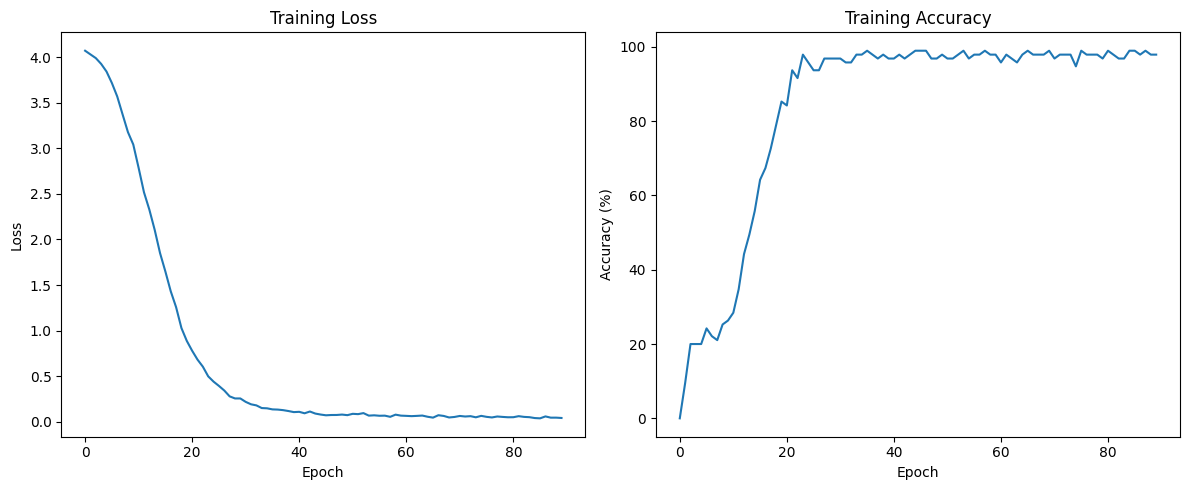

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accuracies)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()

In [ ]:
def generate_text(model, seed_words, num_words=10, temperature=0.8):
    model.eval()
    generated = seed_words.copy()

    for _ in range(num_words):
        seed_tokens = [vocab.get(w, 0) for w in generated[-SEQ_LENGTH:]]
        input_seq = torch.tensor([seed_tokens], dtype=torch.long).to(device)

        with torch.no_grad():
            logits, _ = model(input_seq)
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1).item()

        next_word = idx_to_word.get(next_token, '<UNK>')
        generated.append(next_word)

    return ' '.join(generated)

print("\nText Generation")
print("─" * 40)

seeds = [
    ["machine", "learning", "is"],
    ["an", "artificial", "neural"],
    ["the", "human", "brain"]
]

for seed in seeds:
    output = generate_text(model, seed, num_words=5, temperature=0.7)
    print(f"Seed: {' '.join(seed)} → {output}")


Text Generation
────────────────────────────────────────
Seed: machine learning is → machine learning is a specialized form of machine
Seed: an artificial neural → an artificial neural network the design of such
Seed: the human brain → the human brain humans learn improving improving its
